# Visualizing the Loss Landscape of Neural Nets

In this lab we reproduce (in simplified form) key results from the paper:

> Li, Xu, Taylor, Studer, Goldstein. *Visualizing the Loss Landscape of Neural Nets.* NeurIPS 2018.

We will train small ResNet-style models on FashionMNIST with and without skip connections, then implement the paper's visualization methods to see how architecture choices shape the loss landscape.

### Recommended Reading
1. [Visualizing the Loss Landscape of Neural Nets (arXiv)](https://arxiv.org/abs/1712.09913)
2. [loss-landscape GitHub repository](https://github.com/tomgoldstein/loss-landscape) — authors' original code
3. [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385) — the original ResNet paper

## 1. Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import alpha_gen
from tqdm.auto import tqdm

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

C:\Users\Dominik\AppData\Local\pypoetry\Cache\virtualenvs\agh-stochastic-ml-VnOEU-Hv-py3.11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## 2. Data

We use [FashionMNIST](https://github.com/zalandoresearch/fashion-mnist) — 28x28 grayscale images of clothing items (10 classes). It is harder than MNIST but trains much faster than CIFAR-10 due to the single channel and smaller spatial size.

We train on a **10K subset** to keep training fast on CPU (~30s per model). For loss landscape evaluation we use a separate **1K subset** of the test set.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)


def get_subset_loader(dataset, num_samples: int, batch_size: int = 256, shuffle: bool = False) -> torch.utils.data.DataLoader:
    """Create a DataLoader from a random subset of the dataset."""
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    subset = torch.utils.data.Subset(dataset, indices)
    return torch.utils.data.DataLoader(subset, batch_size=batch_size, shuffle=shuffle, num_workers=2)


TRAIN_SUBSET = 10_000

trainloader = get_subset_loader(trainset, num_samples=TRAIN_SUBSET, batch_size=256, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=512, shuffle=False, num_workers=2)
eval_loader = get_subset_loader(testset, num_samples=1000, batch_size=512)

100%|██████████| 26.4M/26.4M [00:02<00:00, 8.83MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 997kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 9.18MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 1.12MB/s]


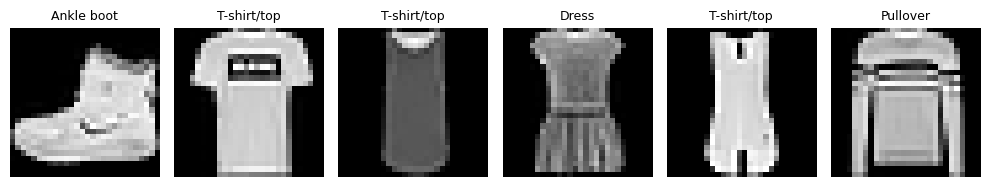

In [3]:
classes = trainset.classes

fig, axes = plt.subplots(1, 6, figsize=(10, 2))

for i, ax in enumerate(axes):
    image, label = trainset[i]

    image = image * 0.3530 + 0.2860

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(classes[label], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Model Architectures

We define a simple ResNet-style architecture with a `use_skip` flag. When `use_skip=True`, the model uses residual connections. When `use_skip=False`, it becomes a plain convolutional network (equivalent to *ResNet-noshort* in the paper).

The architecture has 3 groups of layers with channels `[16, 32, 64]`. The `num_blocks` parameter controls how many basic blocks are in each group: this lets us vary the network depth.

**Depth formula:** total layers = 1 (initial conv) + 2 × sum(num_blocks) + 1 (fc)  
For example: `[3, 3, 3]` → 1 + 18 + 1 = **20 layers**

In [4]:
class BasicBlock(nn.Module):
    """A basic residual block: two 3x3 convolutions with optional skip connection."""

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1, use_skip: bool = True):
        super().__init__()
        self.use_skip = use_skip

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()
        if use_skip and (stride != 1 or in_channels != out_channels):
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.use_skip:
            out += self.shortcut(x)
        out = self.relu(out)
        return out


class SimpleResNet(nn.Module):
    """
    A simplified ResNet for FashionMNIST.

    Architecture: conv -> [group1 x N] -> [group2 x N] -> [group3 x N] -> avgpool -> fc
    Channels:      16       16               32               64
    """

    def __init__(self, num_blocks: list[int] = [3, 3, 3], num_classes: int = 10, use_skip: bool = True):
        super().__init__()
        self.in_channels = 16
        self.use_skip = use_skip

        self.conv1 = nn.Conv2d(1, 16, 3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(64, num_blocks[2], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def _make_layer(self, out_channels: int, num_blocks: int, stride: int) -> nn.Sequential:
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_channels, out_channels, s, self.use_skip))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


model_skip = SimpleResNet(num_blocks=[3, 3, 3], use_skip=True)
model_noskip = SimpleResNet(num_blocks=[3, 3, 3], use_skip=False)

print(f"With skip connections:    {count_parameters(model_skip):,} parameters")
print(f"Without skip connections: {count_parameters(model_noskip):,} parameters")

With skip connections:    272,186 parameters
Without skip connections: 269,434 parameters


## 4. Training

We train both models using SGD with momentum for **10 epochs**.

In [5]:
def train_model(
    model: nn.Module,
    trainloader: torch.utils.data.DataLoader,
    testloader: torch.utils.data.DataLoader,
    epochs: int = 10,
    lr: float = 0.1,
    device: torch.device = device,
) -> tuple[list[float], list[float]]:
    """Train a model and return (train_losses, test_accuracies) per epoch."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    model.to(device)
    train_losses = []
    test_accs = []

    for epoch in tqdm(range(epochs), desc="Training"):
        model.train()
        running_loss = 0.0
        for inputs, targets in trainloader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        scheduler.step()
        train_losses.append(running_loss / len(trainloader))

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, targets in testloader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        acc = 100.0 * correct / total
        test_accs.append(acc)
        print(f"  Epoch {epoch+1}/{epochs} — Loss: {train_losses[-1]:.4f}, Test Acc: {acc:.2f}%")

    return train_losses, test_accs

In [6]:
print("=== Training model WITH skip connections ===")
losses_skip, accs_skip = train_model(model_skip, trainloader, testloader)

print("\n=== Training model WITHOUT skip connections ===")
losses_noskip, accs_noskip = train_model(model_noskip, trainloader, testloader)

=== Training model WITH skip connections ===


Training:  10%|█         | 1/10 [00:25<03:47, 25.30s/it]

  Epoch 1/10 — Loss: 1.0751, Test Acc: 51.54%


Training:  20%|██        | 2/10 [00:49<03:17, 24.70s/it]

  Epoch 2/10 — Loss: 0.6737, Test Acc: 53.51%


...

  Epoch 8/10 — Loss: 0.4067, Test Acc: 83.35%


Training:  90%|█████████ | 9/10 [04:15<00:28, 28.72s/it]

  Epoch 9/10 — Loss: 0.3841, Test Acc: 84.68%


Training: 100%|██████████| 10/10 [04:49<00:00, 28.92s/it]

  Epoch 10/10 — Loss: 0.3538, Test Acc: 84.84%


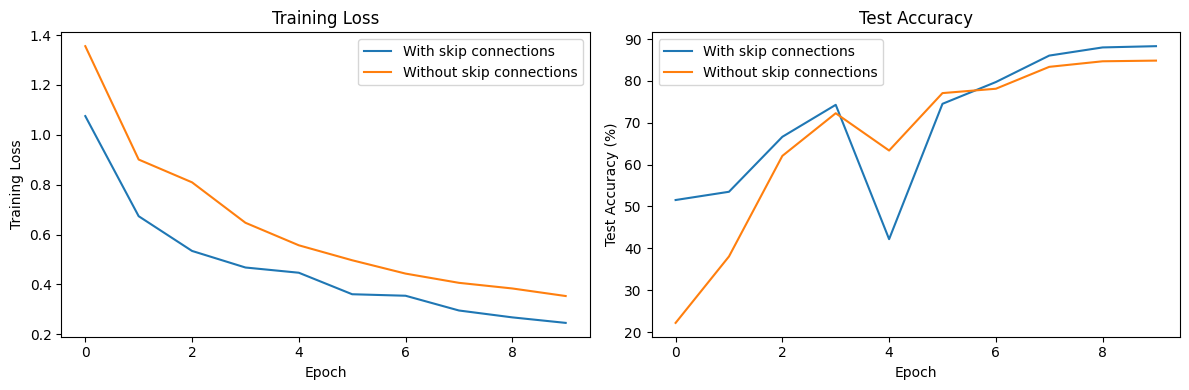

Final test accuracy — with skip: 88.29%, without skip: 84.84%


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses_skip, label="With skip connections")
ax1.plot(losses_noskip, label="Without skip connections")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss")
ax1.set_title("Training Loss")
ax1.legend()

ax2.plot(accs_skip, label="With skip connections")
ax2.plot(accs_noskip, label="Without skip connections")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Test Accuracy (%)")
ax2.set_title("Test Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Final test accuracy — with skip: {accs_skip[-1]:.2f}%, without skip: {accs_noskip[-1]:.2f}%")

## 5. Loss Evaluation Utility

A helper function that computes the average cross-entropy loss of a model on a given dataloader.

In [8]:
@torch.no_grad()
def evaluate_loss(model: nn.Module, dataloader: torch.utils.data.DataLoader, device: torch.device = device) -> float:
    """Compute average cross-entropy loss on the given dataloader."""
    criterion = nn.CrossEntropyLoss()
    model.eval()
    model.to(device)
    total_loss = 0.0
    total_samples = 0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        total_loss += loss.item() * targets.size(0)
        total_samples += targets.size(0)
    return total_loss / total_samples

In [11]:
def get_random_filter_normalized_direction(model: nn.Module) -> list[torch.Tensor]:
    """
    Generate a random direction in parameter space with filter-wise normalization.

    For each parameter tensor theta_{i,j} in the model:
      1. Sample d_{i,j} ~ N(0, 1) with the same shape
      2. Normalize: d_{i,j} <- (d_{i,j} / ||d_{i,j}||) * ||theta_{i,j}||
         - For conv layers (4D), normalize per output filter (dim 0)
         - For other layers, normalize the entire tensor

    Returns:
        A list of tensors, one per model parameter, representing the normalized direction.
    """
    params_list = []
    for name, param in model.named_parameters():
        if param.dim() == 4:
            d = torch.randn_like(param, device="cuda")
            d_norm = d.view(d.size(0), -1).norm(dim=1, keepdim=True)
            theta_norm = param.view(param.size(0), -1).norm(dim=1, keepdim=True)
            d = d / (d_norm.view(-1, 1, 1, 1) + 1e-10)
            d = d * theta_norm.view(-1, 1, 1, 1)

        else:
            d = torch.randn_like(param)
            d = d / (d.norm() + 1e-10) * param.norm()

        params_list.append(d)

    return params_list

In [12]:
# Sanity check: each direction tensor should have the same shape as the corresponding parameter,
# and for conv filters, each filter's norm should match the parameter's filter norm.
direction = get_random_filter_normalized_direction(model_skip)

for d, (name, p) in zip(direction, model_skip.named_parameters()):
    assert d.shape == p.shape, f"Shape mismatch for {name}: {d.shape} vs {p.shape}"
    if p.dim() == 4:  # Conv layer — check per-filter norm
        for j in range(d.size(0)):
            d_norm = d[j].norm().item()
            p_norm = p[j].norm().item()
            assert abs(d_norm - p_norm) < 1e-5, (
                f"Filter norm mismatch for {name}[{j}]: direction={d_norm:.6f}, param={p_norm:.6f}"
            )

print("All checks passed!")

All checks passed!


In [15]:
def compute_loss_1d(
    model: nn.Module,
    direction: list[torch.Tensor],
    dataloader: torch.utils.data.DataLoader,
    alphas: np.ndarray,
    device: torch.device = device,
) -> list[float]:
    """
    Compute the loss along a 1D direction: f(alpha) = L(theta* + alpha * d).

    Args:
        model: Trained model (parameters = theta*).
        direction: Filter-normalized direction (list of tensors, one per parameter).
        dataloader: DataLoader for loss evaluation.
        alphas: Array of alpha values to evaluate.
        device: Computation device.

    Returns:
        List of loss values, one per alpha.
    """
    loss_values = []

    model.eval()
    model.to(device)

    original_params = [param.data.clone() for param in model.parameters()]
    direction = [d.to(device) for d in direction]

    for alpha in alphas:
        alpha = float(alpha)

        for param, orig, d in zip(model.parameters(), original_params, direction):
            param.data = orig + alpha * d

        total_loss = 0.0
        count = 0

        with torch.no_grad():
            for inputs, targets in dataloader:
                inputs, targets = inputs.to(device), targets.to(device)

                outputs = model(inputs)
                loss = torch.nn.functional.cross_entropy(outputs, targets)

                total_loss += loss.item()
                count += 1

        loss_values.append(total_loss / count)

    for param, orig in zip(model.parameters(), original_params):
        param.data = orig

    return loss_values


In [16]:
alphas = np.linspace(-1, 1, 21)

dir_skip = get_random_filter_normalized_direction(model_skip)
dir_noskip = get_random_filter_normalized_direction(model_noskip)

print("Computing 1D landscape for model WITH skip connections...")
losses_1d_skip = compute_loss_1d(model_skip, dir_skip, eval_loader, alphas)

print("Computing 1D landscape for model WITHOUT skip connections...")
losses_1d_noskip = compute_loss_1d(model_noskip, dir_noskip, eval_loader, alphas)

Computing 1D landscape for model WITH skip connections...
Computing 1D landscape for model WITHOUT skip connections...


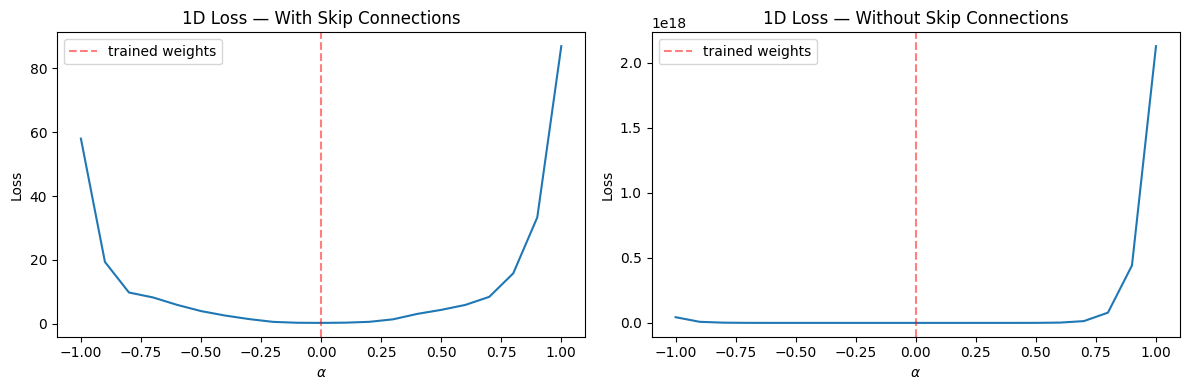

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(alphas, losses_1d_skip)
ax1.axvline(0, color="red", linestyle="--", alpha=0.5, label="trained weights")
ax1.set_xlabel(r"$\alpha$")
ax1.set_ylabel("Loss")
ax1.set_title("1D Loss — With Skip Connections")
ax1.legend()

ax2.plot(alphas, losses_1d_noskip)
ax2.axvline(0, color="red", linestyle="--", alpha=0.5, label="trained weights")
ax2.set_xlabel(r"$\alpha$")
ax2.set_ylabel("Loss")
ax2.set_title("1D Loss — Without Skip Connections")
ax2.legend()

plt.tight_layout()
plt.show()

In [27]:
from torch.nn.functional import cross_entropy


def compute_loss_2d(
    model: nn.Module,
    direction1: list[torch.Tensor],
    direction2: list[torch.Tensor],
    dataloader: torch.utils.data.DataLoader,
    alphas: np.ndarray,
    betas: np.ndarray,
    device: torch.device = device,
) -> np.ndarray:
    """
    Compute loss on a 2D grid: f(alpha, beta) = L(theta* + alpha * d1 + beta * d2).

    Args:
        model: Trained model (parameters = theta*).
        direction1: First filter-normalized direction (delta).
        direction2: Second filter-normalized direction (eta).
        dataloader: DataLoader for loss evaluation.
        alphas: Array of alpha values (x-axis).
        betas: Array of beta values (y-axis).
        device: Computation device.

    Returns:
        2D numpy array of shape (len(betas), len(alphas)) with loss values.
    """
    model.eval()
    model.to(device)


    direction1 = [d.to(device) for d in direction1]
    direction2 = [d.to(device) for d in direction2]
    original_params = [p.data.clone().to(device) for p in model.parameters()]

    loss_grid = np.zeros((len(betas), len(alphas)))

    with torch.no_grad():

        for i, beta in enumerate(betas):
            beta = float(beta)

            for j, alpha in enumerate(alphas):
                alpha = float(alpha)

                for param, orig, d1, d2 in zip(
                    model.parameters(),
                    original_params,
                    direction1,
                    direction2,
                ):
                    param.copy_(orig + alpha * d1 + beta * d2)

                total_loss = 0.0
                count = 0

                for inputs, targets in dataloader:
                    inputs = inputs.to(device, non_blocking=True)
                    targets = targets.to(device, non_blocking=True)

                    outputs = model(inputs)
                    loss = cross_entropy(outputs, targets)

                    total_loss += loss
                    count += 1

                loss_grid[i, j] = (total_loss / count).item()

    for param, orig in zip(model.parameters(), original_params):
        param.copy_(orig)

    return loss_grid

In [28]:
GRID_SIZE = 11  # increase to 21 for smoother plots if you have a GPU
grid_points = np.linspace(-1, 1, GRID_SIZE)
dir1_skip = get_random_filter_normalized_direction(model_skip)
dir2_skip = get_random_filter_normalized_direction(model_skip)

dir1_noskip = get_random_filter_normalized_direction(model_noskip)
dir2_noskip = get_random_filter_normalized_direction(model_noskip)

print(f"Computing 2D landscape ({GRID_SIZE}x{GRID_SIZE} grid)...")

print("  Model WITH skip connections...")
grid_skip = compute_loss_2d(model_skip, dir1_skip, dir2_skip, eval_loader, grid_points, grid_points)

print("  Model WITHOUT skip connections...")
grid_noskip = compute_loss_2d(model_noskip, dir1_noskip, dir2_noskip, eval_loader, grid_points, grid_points)

Computing 2D landscape (11x11 grid)...
  Model WITH skip connections...


RuntimeError: a leaf Variable that requires grad is being used in an in-place operation.

In [ ]:
def plot_loss_contour(
    grid: np.ndarray, alphas: np.ndarray, betas: np.ndarray, title: str, ax=None, vmax: float | None = None,
) -> None:
    """Plot a 2D loss contour map."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    A, B = np.meshgrid(alphas, betas)
    plot_grid = np.log(grid) if grid.min() > 0 else grid
    if vmax is not None:
        plot_grid = np.clip(plot_grid, None, vmax)
    cf = ax.contourf(A, B, plot_grid, levels=30, cmap=cm.viridis)
    ax.contour(A, B, plot_grid, levels=30, colors="k", linewidths=0.3, alpha=0.5)
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\beta$")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.plot(0, 0, "r*", markersize=12, label=r"$\theta^*$")
    ax.legend()
    plt.colorbar(cf, ax=ax, label="log(Loss)")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

vmax = max(np.log(grid_skip).max(), np.log(grid_noskip).max())
plot_loss_contour(grid_skip, grid_points, grid_points, "With Skip Connections", ax=ax1, vmax=vmax)
plot_loss_contour(grid_noskip, grid_points, grid_points, "Without Skip Connections", ax=ax2, vmax=vmax)

plt.suptitle("2D Loss Landscape", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Exercise 4: Comparison and Analysis

**Tasks:**

1. **Compare the 1D plots**: How do the curves differ between the model with skip connections and the one without? Which has a wider "valley" around the minimum?

2. **Compare the 2D contour plots**: Describe the shape differences. Are the contours more circular or elongated? Does the minimum appear sharper or flatter?

3. **Normalized vs. unnormalized directions**: Generate a direction **without** filter normalization (just `torch.randn_like(p)` for each parameter) and create the same 1D plot.

4. **Relate to training**: How do the landscape differences connect to the training curves you observed (loss convergence speed, final test accuracy)?

## Discussion Questions

1. The paper claims that skip connections "prevent the explosion of non-convexity" as depth increases. Based on your experiments, do you agree? What mechanism might explain this?

2. Why is filter normalization essential for comparing loss landscapes across different architectures? What would go wrong without it?

3. The paper found that large-batch training produces sharper minima and worse generalization. How could you test this using the tools you've built in this lab?